In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ulmekenshaidyr/co2-dataset/owid-co2-data.csv")
filtered_NL = df[df['country']=='United Kingdom']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [3]:
europe = ['Germany', 'France', 'Italy', 'Norway', 'Netherlands','Switzerland','Hungary','Spain','United Kingdom']
df_eu_from_2018=df[(df['country'].isin(europe))&(df['year']>=2018)]

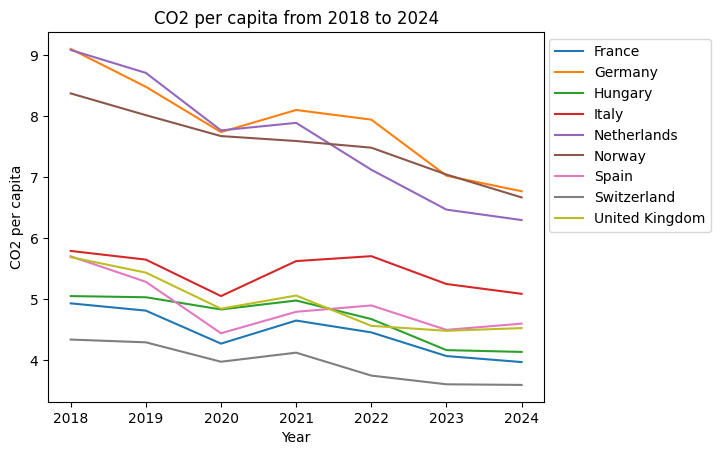

In [4]:
for country, group in df_eu_from_2018.groupby('country'):
    plt.plot(group['year'],group['co2_per_capita'],label=country)
    plt.title('CO2 per capita from 2018 to 2024')
    plt.xlabel('Year')
    plt.ylabel('CO2 per capita')

plt.legend(bbox_to_anchor=(1.35, 1), loc='upper right')
plt.show()

From the trend line above it can be seen that the picture can be separated to two main focus areas top (emissions range from 9 to 7) and bottom (emissions range from 6 to 4). 
At the top part major contributors observed are Netherlands, Norway, Germany. While in 2018 Germany and Netherlands were at about the same level of 9 emissions of CO2 per capita, over the span of 6 years Netherlands made a huge improvement of reducing those emissions landing as the least emitting country out of the top 3 countries. Germany, on the other hand, became the highest CO2 emitter per capita, with Norway standing slightly below that point.
On the bottom section of the graph rest of the countries distinguished are United Kingdom, Spain, Hungary, France, Switzerland with the lead of Italy. Order of those countries by the most to the least contributing have not changed significantly over the selected years of 2018 to 2024. The fluctuation between Hungary, Spain and United Kingdom is the most prominent from 2020 and 2022, where Hungary was at the same trend line as United Kingdom. However, by 2024 it recovered to the level noticeably lower of its initial in 2018. France and Switzerland were able to maintain and isolate from intersecting their trend lines with other countries as the least 2 contributors to CO2 emissions Switzeland being the lowest rank of two.
Overall, for all the countries one common reduction of CO2 emissions in 2020 is highly visible connected to the COVID pandemic and the shut down of production related to it. Progress toward SDG 13 (Climate Action) is visible across all countries, with emissions consistently below 2018 levels.

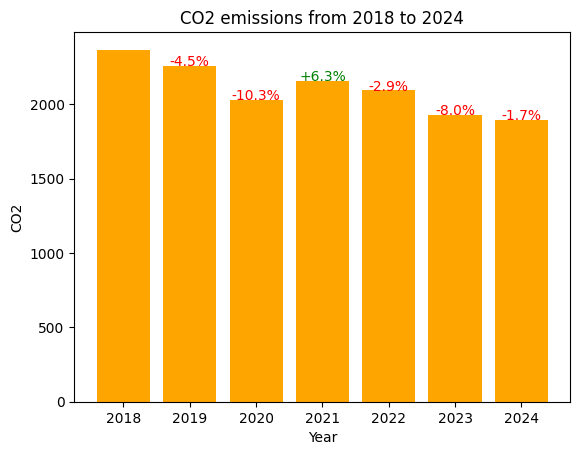

In [5]:
co2_year = df_eu_from_2018.groupby('year')['co2'].sum().reset_index()
co2_year['% growth YoY']=co2_year['co2'].pct_change()
plt.bar(co2_year['year'], co2_year['co2'], color='orange')
plt.title('CO2 emissions from 2018 to 2024')
plt.xlabel('Year')
plt.ylabel('CO2')
for i in range(len(co2_year)):
    value = co2_year['co2'][i]
    growth = co2_year['% growth YoY'][i]
    if pd.notna(growth):
        color = 'green' if growth > 0 else 'red'
        plt.text(x=co2_year['year'][i],y=value,s=f"{growth:+.1%}",ha='center',color=color)
plt.show()

The bar chart above depicts the total CO2 emissions from 2018 to 2024. On top of each bar the YoY growth in percentage is shown. 
From the trend above it can be seen that 2018 has the highest amount of CO2 emissions from all of the years, staying just under 2400. Then, after slight decrease in 2019 there was a significant reduction of 10.3% compared to 2019 level due to the COVID pandemic in 2020. In 2021 after strict pandemic rules weakening the production of CO2 emissions increased by 6.3%, which is still lower than 2019 level. From 2022 to 2024 the declining trend of CO2 emissions is consistent, though the transition from 2023 to 2024 is slight, e.g. 1.7% decrease from 2023 level.
Overall, total CO2 emissions declined by approximately 19-20% between 2018 and 2024, suggesting meaningful but still insufficient progress toward net-zero targets.

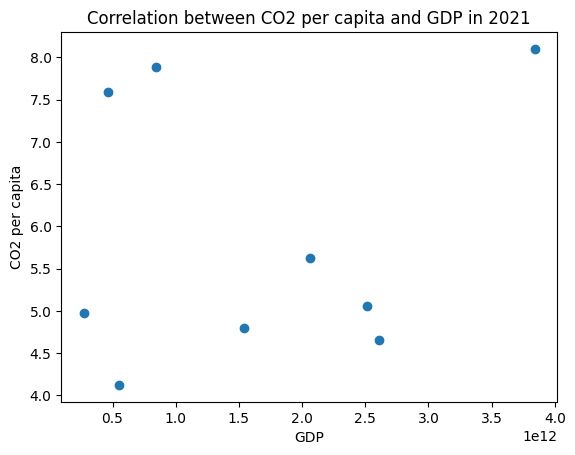

In [6]:
df_eu_2021=df_eu_from_2018[df_eu_from_2018['year']==2021]
plt.scatter(df_eu_2021['gdp'], df_eu_2021['co2_per_capita'])
plt.title('Correlation between CO2 per capita and GDP in 2021')
plt.xlabel('GDP')
plt.ylabel('CO2 per capita')
plt.show()

The scatter plot does not reveal a strong or consistent linear correlation between GDP and CO₂ per capita across the selected countries in 2021. However, a general tendency can be observed — the country with the highest GDP (around 3.8×10^12) also records the highest CO₂ per capita at 8.1, while countries with mid-range GDP show more varied emissions levels. This suggests that GDP alone is not a sufficient predictor of per capita emissions — energy mix, industrial structure, and climate policy likely play equally significant roles.